In [103]:
using Distributions, Random, LinearAlgebra, Plots

include("../src/bandeirante/julia_markov.jl")

simulate_hmm (generic function with 1 method)

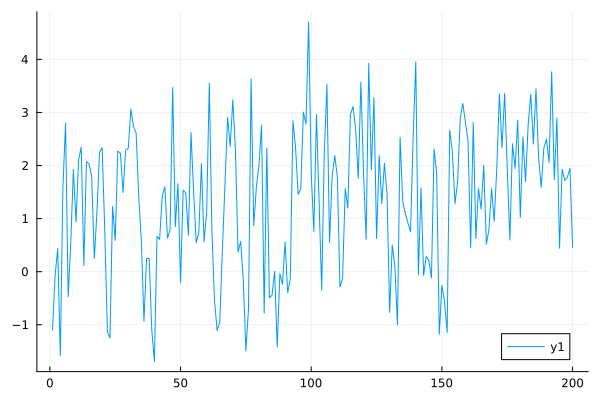

In [104]:
plot(x)

In [105]:
A = [
    0.7 0.3;
    0.1 0.9
]

π = [0.6, 0.4]

μ = [0.0, 2.0]
σ = [1.0, 1.0]

z, x = simulate_hmm(A, π, μ, σ, 200)

([1, 1, 1, 1, 1, 1, 2, 2, 2, 2  …  1, 2, 2, 2, 2, 1, 1, 2, 2, 2], [-0.17555464943572524, 1.6338804689270578, -0.2927961691310267, 1.530188338459162, 0.5630988314510778, -0.3469542302222103, 1.9795076724885639, 2.9108005952048264, 2.466416435881007, 1.6277970340629881  …  -0.029940967653899694, 1.7078079807722164, 2.6254965673188444, 0.053150651998885134, 3.5662111659962292, 0.45283780226333464, -0.008923297182436398, 1.046936784390954, 2.9339726943920112, 2.2729490608618392])

In [126]:
s = 2

A_find, B, P_0, μ, σ = EM_algorithm(x,s)

states,state_probs = viterbi(x,A,B,P_0)


([1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [0.11845341496596469 0.0; 0.027708489060077994 0.0; … ; 9.129269342708961e-164 0.0; 1.8471944616636343e-164 0.0])

In [109]:
sum(states.==1)

30

In [108]:
n, = size(x)

past_likehood = -Inf
δ = Inf

A,P_0 = initialize_parameters(s)

μ,σ,vector_of_distribs = initialize_gaussian(s)

B_func(x) = stack([pdf.(dist,x) for dist in vector_of_distribs])
B = B_func(x)

alpha = zeros(n,s)
scale = zeros(n)

alpha[1,:] = P_0.*B[1,:]
scale[1] = sum(alpha[1,:]) 
alpha[1,:] /= scale[1]


for t = 2:n
    alpha[t,:] = (alpha[t-1,:]'*A).*B[t,:]
    scale[t] = sum(alpha[t,:]) 
    alpha[t,:] = alpha[t,:]/scale[t]
end

LoadError: cannot assign a value to imported variable Distributions.scale from module Main